HEART DISEASE PREDICTION USING SUPPORT VECTOR MACHINE

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, 
                          confusion_matrix, roc_auc_score, roc_curve, 
                          precision_recall_curve, f1_score)
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

Load Heart Disease Data

In [2]:
# Load the dataset
print("Loading Heart Disease Dataset...")
df = pd.read_csv('heart_statlog_cleveland_hungary_final.csv')


Loading Heart Disease Dataset...


In [3]:
list(df.columns)

['age',
 'sex',
 'chest pain type',
 'resting bp s',
 'cholesterol',
 'fasting blood sugar',
 'resting ecg',
 'max heart rate',
 'exercise angina',
 'oldpeak',
 'ST slope',
 'target']

In [4]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
display(df.head())


Dataset Shape: (1190, 12)

First 5 rows of the dataset:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [5]:
print("\nDataset Information:")
print(df.info())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB
None


In [6]:
print("\nBasic Statistics:")
display(df.describe())



Basic Statistics:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [7]:
# Check for missing values
print("Missing Values Analysis:")
missing_data = df.isnull().sum()


if missing_data.sum() == 0:
    print("No missing values found in the dataset!")
else:
    print(missing_data[missing_data > 0])
    print(f"Total missing values: {missing_data.sum()}")

Missing Values Analysis:
No missing values found in the dataset!


# Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Heart Disease Distribution')

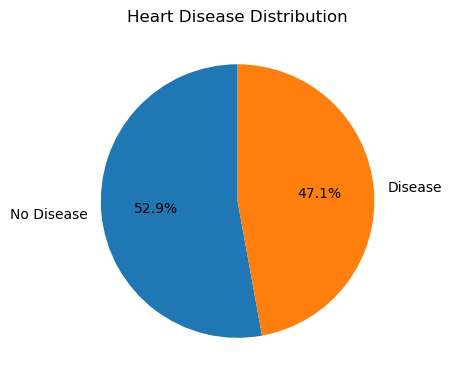

In [8]:
# 1. Target variable distribution
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
target_counts = df['target'].value_counts()
plt.pie(target_counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%', startangle=90)
plt.title('Heart Disease Distribution')

Text(0, 0.5, 'Count')

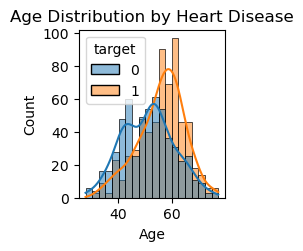

In [9]:
# 2. Age distribution by target
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')


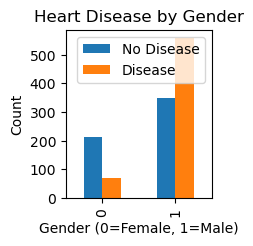

In [10]:
# 3. Gender distribution by target
plt.subplot(2, 3, 3)
gender_target = pd.crosstab(df['sex'], df['target'])
gender_target.plot(kind='bar', ax=plt.gca())
plt.title('Heart Disease by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Count')
plt.legend(['No Disease', 'Disease'])


Text(0, 0.5, 'Cholesterol')

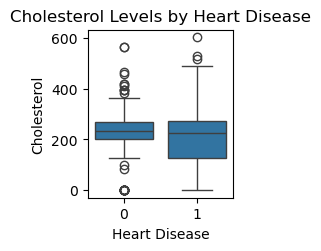

In [11]:
# 4. Cholesterol distribution
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='target', y='cholesterol')
plt.title('Cholesterol Levels by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Cholesterol')


Text(0, 0.5, 'Resting BP (mm Hg)')

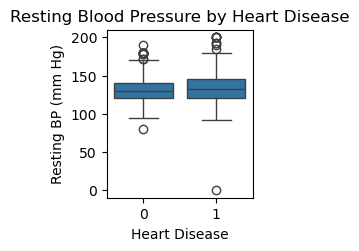

In [12]:
# 5. Blood pressure distribution
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='target', y='resting bp s')
plt.title('Resting Blood Pressure by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Resting BP (mm Hg)')

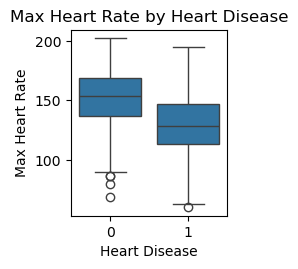

In [13]:
# 6. Max heart rate distribution
plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='target', y='max heart rate')
plt.title('Max Heart Rate by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Max Heart Rate')

plt.tight_layout()
plt.show()

Correlation Analysis

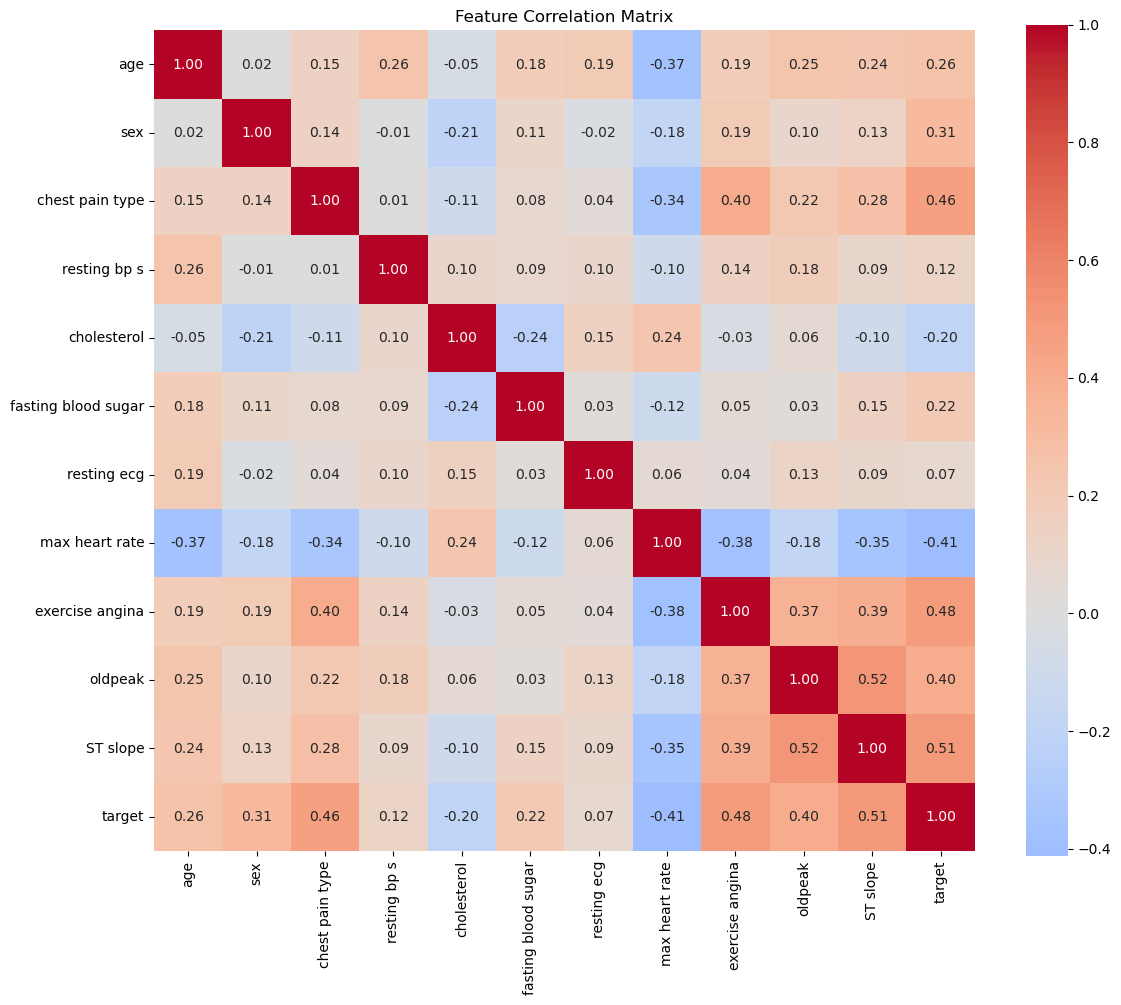

In [14]:
# Correlation Analysis
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()



sns.heatmap(correlation_matrix,  annot=True, cmap='coolwarm', 
           center=0, square=True, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


 Feature Engineering and Preprocessing


In [15]:
# Feature Engineering and Preprocessing

print("Feature Engineering and Preprocessing...")

# Create a copy of the dataset for preprocessing
df_processed = df.copy()

Feature Engineering and Preprocessing...


In [16]:
# Feature: Age categories
df_processed['age_category'] = pd.cut(df_processed['age'], 
                                    bins=[0, 40, 50, 60, 100], 
                                    labels=['Young', 'Middle', 'Senior', 'Elderly'])

In [17]:
# Feature: Cholesterol categories
df_processed['chol_category'] = pd.cut(df_processed['cholesterol'],
                                     bins=[0, 200, 240, 1000],
                                     labels=['Normal', 'Borderline', 'High'])

In [18]:
 #Feature: Blood pressure categories
df_processed['bp_category'] = pd.cut(df_processed['resting bp s'],
                                   bins=[0, 120, 130, 140, 1000],
                                   labels=['Normal', 'Elevated', 'High-Stage1', 'High-Stage2'])


In [19]:
# Display new features
print("New engineered features:")
print(df_processed[['age_category', 'chol_category', 'bp_category']].head())

New engineered features:
  age_category chol_category  bp_category
0        Young          High  High-Stage1
1       Middle        Normal  High-Stage2
2        Young          High     Elevated
3       Middle    Borderline  High-Stage1
4       Senior        Normal  High-Stage2


Prepare data for modeling

In [20]:
# Prepare data for modeling
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print("Original Features:", X.columns.tolist())
print("Target variable distribution:")
print(y.value_counts())
df_processed.head()

Original Features: ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope']
Target variable distribution:
target
1    629
0    561
Name: count, dtype: int64


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,age_category,chol_category,bp_category
0,40,1,2,140,289,0,0,172,0,0.0,1,0,Young,High,High-Stage1
1,49,0,3,160,180,0,0,156,0,1.0,2,1,Middle,Normal,High-Stage2
2,37,1,2,130,283,0,1,98,0,0.0,1,0,Young,High,Elevated
3,48,0,4,138,214,0,0,108,1,1.5,2,1,Middle,Borderline,High-Stage1
4,54,1,3,150,195,0,0,122,0,0.0,1,0,Senior,Normal,High-Stage2


In [21]:
 #Handle categorical variables (if any)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=[np.number]).columns

print("Categorical columns:", categorical_cols.tolist())
print("Numerical columns:", numerical_cols.tolist())
# If there were categorical columns, we would encode them
# For this dataset, all features are numerical


Categorical columns: []
Numerical columns: ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope']


feature selection

In [22]:
# Feature Selection using ANOVA F-value
print("Performing Feature Selection...")

# Select top k features
k = 8  # You can adjust this based on your needs
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X, y)


Performing Feature Selection...


In [23]:
# Get selected feature names
selected_features = X.columns[selector.get_support()].tolist()
feature_scores = selector.scores_[selector.get_support()]

print(f"Top {k} selected features:")
for feature, score in zip(selected_features, feature_scores):
    print(f"{feature}: {score:.2f}")
    # Use selected features
X = X[selected_features]

Top 8 selected features:
age: 87.58
sex: 127.45
chest pain type: 319.07
fasting blood sugar: 58.53
max heart rate: 244.70
exercise angina: 358.49
oldpeak: 224.12
ST slope: 408.00


Split Data

In [24]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts()}")
print(f"Testing target distribution:\n{y_test.value_counts()}")

Training set size: (952, 8)
Testing set size: (238, 8)
Training target distribution:
target
1    503
0    449
Name: count, dtype: int64
Testing target distribution:
target
1    126
0    112
Name: count, dtype: int64


In [25]:
# Feature Scaling (Crucial for SVM)
print("Scaling features...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print(f"Training set scaled shape: {X_train_scaled.shape}")
print(f"Testing set scaled shape: {X_test_scaled.shape}")


Scaling features...
Feature scaling completed!
Training set scaled shape: (952, 8)
Testing set scaled shape: (238, 8)


In [26]:
# Support Vector Machine Model Building

print("Building SVM Model...")

# Initialize SVM classifier
svm_model = SVC(random_state=42, probability=True)

svm_model

Building SVM Model...


SVC(probability=True, random_state=42)

In [27]:
# Define hyperparameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'degree': [2, 3]  # Only for poly kernel
}

print("Performing Hyperparameter Tuning with GridSearchCV...")

Performing Hyperparameter Tuning with GridSearchCV...


In [28]:
# Perform grid search with cross-validation
grid_search = GridSearchCV(
    svm_model, param_grid, cv=5, scoring='accuracy', 
    n_jobs=-1, verbose=1
)

In [29]:
# Fit the model
grid_search.fit(X_train_scaled, y_train)

# Get best parameters and model
best_params = grid_search.best_params_
best_svm = grid_search.best_estimator_

print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score: 0.8488


In [30]:
# Model Evaluation

print("Evaluating SVM Model...")

# Predictions
y_pred = best_svm.predict(X_test_scaled)
y_pred_proba = best_svm.predict_proba(X_test_scaled)[:, 1]


Evaluating SVM Model...


In [31]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("MODEL EVALUATION RESULTS")

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"F1 Score: {f1:.4f}")


MODEL EVALUATION RESULTS
Accuracy: 0.8487
AUC Score: 0.9336
F1 Score: 0.8560


In [32]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.83      0.85      0.84       112
     Disease       0.86      0.85      0.86       126

    accuracy                           0.85       238
   macro avg       0.85      0.85      0.85       238
weighted avg       0.85      0.85      0.85       238



Text(0.5, 25.722222222222214, 'Predicted')

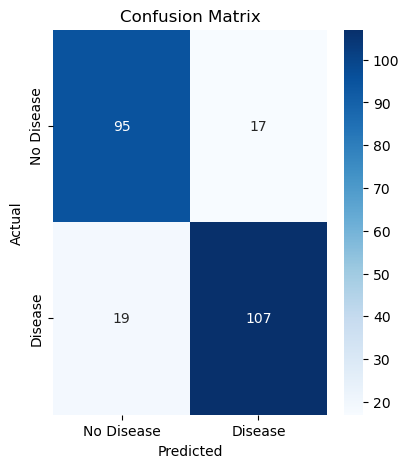

In [33]:
# Confusion Matrix
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['No Disease', 'Disease'],
           yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

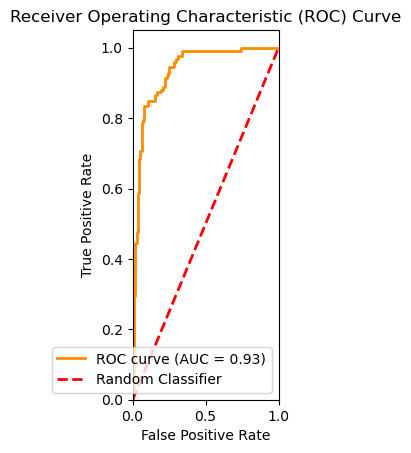

In [34]:
# ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")


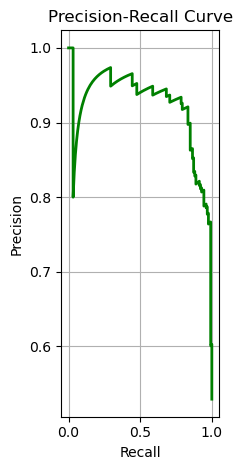

In [35]:
# Precision-Recall Curve
plt.subplot(1, 3, 3)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)

plt.tight_layout()
plt.show()



In [36]:
 #Cross-Validation Scores
print("Performing Cross-Validation...")

cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Performing Cross-Validation...
Cross-Validation Scores: [0.84816754 0.82198953 0.84736842 0.84736842 0.87894737]
Mean CV Accuracy: 0.8488 (+/- 0.0361)


In [37]:
# Feature Importance Analysis (for linear kernel)
if best_params['kernel'] == 'linear':
    print("Feature Importance (Linear SVM Coefficients):")
    feature_importance = pd.DataFrame({
        'feature': selected_features,
        'importance': abs(best_svm.coef_[0])
    }).sort_values('importance', ascending=False)
    
    print(feature_importance)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature')
    plt.title('Feature Importance (SVM Coefficients)')
    plt.xlabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.show()

In [38]:
# Model Interpretation and Business Insights

print("BUSINESS INSIGHTS AND MODEL INTERPRETATION")

# Feature analysis for insights
feature_analysis = pd.DataFrame({
    'No_Disease_Mean': X_train[y_train == 0].mean(),
    'Disease_Mean': X_train[y_train == 1].mean(),
    'Difference': X_train[y_train == 1].mean() - X_train[y_train == 0].mean()
}).sort_values('Difference', key=abs, ascending=False)

print("\nFeature Analysis (Difference between Disease vs No Disease):")
display(feature_analysis)


BUSINESS INSIGHTS AND MODEL INTERPRETATION

Feature Analysis (Difference between Disease vs No Disease):


,No_Disease_Mean,Disease_Mean,Difference
max heart rate,150.438753,130.310139,-20.128614
age,51.227171,56.268390,5.041218
oldpeak,0.484855,1.364016,0.879161
chest pain type,2.779510,3.620278,0.840768
ST slope,1.305122,1.920477,0.615355
exercise angina,0.140312,0.610338,0.470026
sex,0.614699,0.882704,0.268004
fasting blood sugar,0.109131,0.290258,0.181127


In [39]:
# Key insights
print("\nKey Insights:")
print("1. Features with largest differences between groups:")
for i, (feature, row) in enumerate(feature_analysis.head(3).iterrows()):
    print(f"   {i+1}. {feature}: Difference = {row['Difference']:.2f}")



Key Insights:
1. Features with largest differences between groups:
   1. max heart rate: Difference = -20.13
   2. age: Difference = 5.04
   3. oldpeak: Difference = 0.88


 Prediction on New Data
 

In [40]:
def heart_disease_predictor():
    print("HEART DISEASE PREDICTION SYSTEM")
    
    
    # Get patient data through user input
    print("Please enter patient information:")
    
    age = int(input("Age (years): "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))
    chest_pain = int(input("Chest Pain Type (0-3): "))
    blood_sugar = int(input("Fasting Blood Sugar (0 = Normal, 1 = High): "))
    max_hr = int(input("Maximum Heart Rate: "))
    exercise_angina = int(input("Exercise Angina (0 = No, 1 = Yes): "))
    
    # Safe input for Oldpeak
    oldpeak_input = input("Oldpeak: ")
    oldpeak = float(oldpeak_input) if oldpeak_input.strip() != "" else 0.0
    
    # Safe input for ST Slope
    st_slope_input = input("ST Slope (0-2): ")
    st_slope = int(st_slope_input) if st_slope_input.strip() != "" else 0
    
    # Create patient data
    patient_data = [[age, sex, chest_pain, blood_sugar, max_hr, exercise_angina, oldpeak, st_slope]]
    
    # Scale and predict
    patient_scaled = scaler.transform(patient_data)
    prediction = best_svm.predict(patient_scaled)[0]
    probability = best_svm.predict_proba(patient_scaled)[0]
    
    # Display COMPLETE results with patient information
    
    print(" COMPLETE PREDICTION REPORT")
    
    
    # Display patient information
    print(" PATIENT INFORMATION:")
    print(f"   • Age: {age} years")
    print(f"   • Sex: {'Male' if sex == 1 else 'Female'}")
    print(f"   • Chest Pain Type: {chest_pain}")
    print(f"   • Fasting Blood Sugar: {'High' if blood_sugar == 1 else 'Normal'}")
    print(f"   • Maximum Heart Rate: {max_hr} bpm")
    print(f"   • Exercise Angina: {'Yes' if exercise_angina == 1 else 'No'}")
    print(f"   • Oldpeak: {oldpeak}")
    print(f"   • ST Slope: {st_slope}")
    

    print(" PREDICTION RESULTS:")
    
    
    if prediction == 1:
        print("HIGH RISK: Heart Disease Detected")
        print(f"   Confidence Level: {probability[1]:.1%}")
        print(f"   Risk Probability: {probability[1]:.3f}")
    else:
        print("LOW RISK: No Heart Disease")
        print(f"   Confidence Level: {probability[0]:.1%}")
        print(f"   Risk Probability: {probability[1]:.3f}")
    
    
    print(" RECOMMENDATION:")
    
    if prediction == 1:
        if probability[1] > 0.8:
            print("    Immediate medical consultation advised")
            print("    Consider visiting a cardiologist soon")
        elif probability[1] > 0.6:
            print("    Further medical evaluation recommended")
            print("   Schedule a check-up with your doctor")
        else:
            print("    Consult with healthcare provider")
            print("    Maintain regular health monitoring")
    else:
        if probability[0] > 0.8:
            print("    Excellent heart health indicators")
            print("    Continue healthy lifestyle habits")
        else:
            print("   Good heart health")
            print("   Regular exercise and balanced diet recommended")
    


# Run the predictor
heart_disease_predictor()

HEART DISEASE PREDICTION SYSTEM
Please enter patient information:
 COMPLETE PREDICTION REPORT
 PATIENT INFORMATION:
   • Age: 12 years
   • Sex: Female
   • Chest Pain Type: 2
   • Fasting Blood Sugar: High
   • Maximum Heart Rate: 120 bpm
   • Exercise Angina: No
   • Oldpeak: 10.0
   • ST Slope: 0
 PREDICTION RESULTS:
HIGH RISK: Heart Disease Detected
   Confidence Level: 82.8%
   Risk Probability: 0.828
 RECOMMENDATION:
    Immediate medical consultation advised
    Consider visiting a cardiologist soon


Generating Learning Curve...


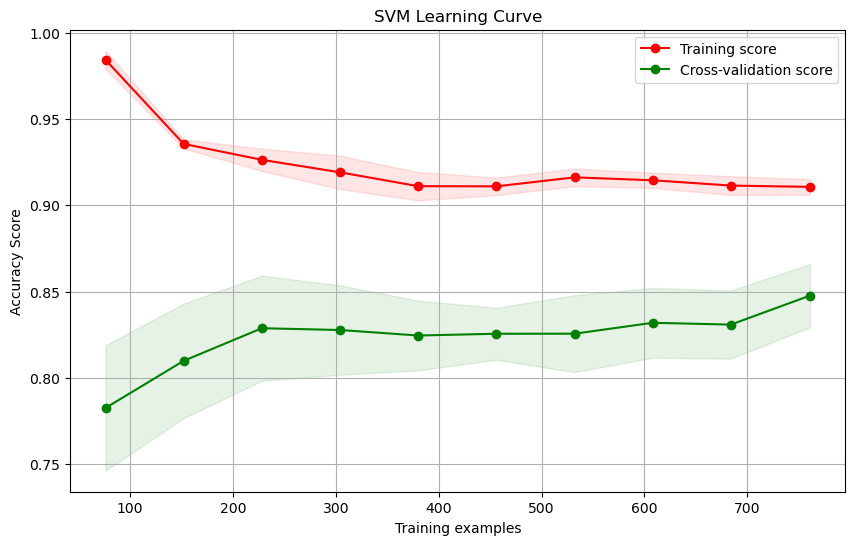

In [41]:
# Advanced Analysis: Learning Curve (Optional)
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Generate a simple plot of the learning curve.
    """
    plt.figure(figsize=(10, 6))
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring='accuracy', n_jobs=-1
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy Score")
    plt.title(title)
    plt.legend(loc="best")
    plt.show()

print("Generating Learning Curve...")
plot_learning_curve(best_svm, "SVM Learning Curve", X_train_scaled, y_train)


In [42]:
# Final Summary
print("FINAL SUMMARY")

print(f"Model Type: Support Vector Machine ({best_params['kernel']} kernel)")
print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Final AUC Score: {auc_score:.4f}")
print(f"Key Features Used: {', '.join(selected_features)}")
print(f"Best Hyperparameters: {best_params}")

print("\nModel is ready for heart disease prediction!")

FINAL SUMMARY
Model Type: Support Vector Machine (rbf kernel)
Final Test Accuracy: 0.8487
Final AUC Score: 0.9336
Key Features Used: age, sex, chest pain type, fasting blood sugar, max heart rate, exercise angina, oldpeak, ST slope
Best Hyperparameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}

Model is ready for heart disease prediction!


In [43]:
import pickle

model_data = {
    "model": best_svm,               # trained SVM
    "scaler": scaler,                # StandardScaler
    "features": selected_features    # correct feature order
}

with open("heart_disease_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("✔ Model, scaler, and selected features saved!")


✔ Model, scaler, and selected features saved!


In [44]:
import pickle

with open("heart_disease_model.pkl", "rb") as f:
    obj = pickle.load(f)

print("TYPE:", type(obj))

if isinstance(obj, dict):
    print("OK, keys:", obj.keys())
else:
    print("WRONG FILE: contains only", type(obj))


TYPE: <class 'dict'>
OK, keys: dict_keys(['model', 'scaler', 'features'])


In [45]:
with open("heart_disease_model.pkl", "rb") as f:
    obj = pickle.load(f)

print(obj.keys())


dict_keys(['model', 'scaler', 'features'])
